In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

d:\Tipto\agentic-ai\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class BatsmanState(TypedDict):
    # these are inputs
    runs: int 
    balls: int
    fours: int 
    sixes: int 
    # need to calculate
    strike_rate: float
    ball_per_boundary: float
    boundary_percent: float
    summary: str

In [3]:
def calculate_strike_rate(state: BatsmanState):
    strike_rate = (state['runs'] / state['balls']) * 100
    return {"strike_rate": strike_rate}

def calculate_ball_per_boundary(state: BatsmanState):
    ball_per_boundary = state['balls'] / (state['fours'] + state['sixes'])
    return {"ball_per_boundary": ball_per_boundary}

def calculate_boundary_rate(state: BatsmanState):
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {"boundary_percent": boundary_percent} 

def summary(state: BatsmanState):
    summary = f""" 
    Strike Rate: {state['strike_rate']} \n 
    Balls per boundary: {state['ball_per_boundary']} \n 
    Boundary rate: {state['boundary_percent']}
    """
    return {"summary": summary} 

In [4]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate" , calculate_strike_rate)
graph.add_node("calculate_boundary_rate" , calculate_boundary_rate)
graph.add_node("calculate_ball_per_boundary" , calculate_ball_per_boundary)
graph.add_node("summary" , summary)

# define edges
graph.add_edge(START , "calculate_strike_rate")
graph.add_edge(START , "calculate_boundary_rate")
graph.add_edge(START , "calculate_ball_per_boundary")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_boundary_rate", "summary")
graph.add_edge("calculate_ball_per_boundary", "summary")

graph.add_edge("summary", END)

batsman_workflow = graph.compile()

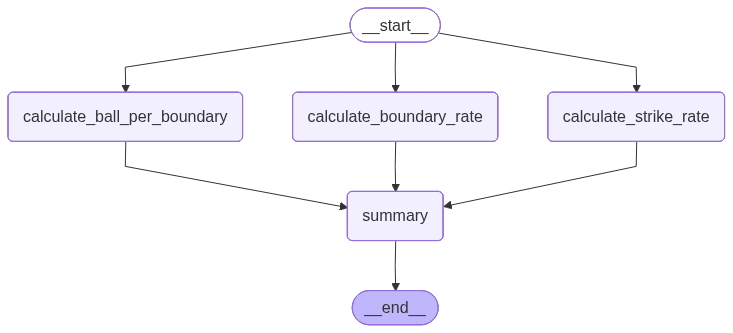

In [5]:
batsman_workflow

In [6]:
initial_state = {
    "runs": 123, 
    "balls": 55,
    "fours": 15, 
    "sixes": 7,
}

final_state = batsman_workflow.invoke(initial_state)
final_state

{'runs': 123,
 'balls': 55,
 'fours': 15,
 'sixes': 7,
 'strike_rate': 223.63636363636363,
 'ball_per_boundary': 2.5,
 'boundary_percent': 82.92682926829268,
 'summary': ' \n    Strike Rate: 223.63636363636363 \n \n    Balls per boundary: 2.5 \n \n    Boundary rate: 82.92682926829268\n    '}

### Make a parallel workflow:
- We will provide a a topic.
- First LLM will write a outline on this topic.
- Then second llm will write a blog by following the outline.
- Third LLM Agent will check the blog on following things and provides scores from 0 to 10.
   - CoT => Cleariety of Thought
   - DoA => Depth of Analysis
   - Language

In [8]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
# define the model
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen2.5-7B-Instruct",
    task = "text-generation",
    temperature = 0.7,
)
model_qwen = ChatHuggingFace(llm = llm)

In [12]:
model_mistral = ChatMistralAI(
    model = "mistral-small-latest",
    temperature = 0.7
)
model_mistral.invoke("Hello").content

'Hello! 😊 How can I assist you today?'

In [27]:
import os 

In [42]:
from langchain_ollama import ChatOllama

model_phi = ChatOllama(
    model = "phi4-mini:latest",
    temperature = 0.7
)

In [43]:
model_phi.invoke("Hello").content

'Hi there! How can I assist you today?'

In [44]:
# Define the structure(what we want as output)
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, List
import operator

In [45]:
class EvaluationSchema(BaseModel):
    metric: str
    feedback: str = Field(
        description = "Give a feedback based on the corresponding to the evaluation metric"
    )
    score: float = Field(
        description = "Score this on scale 0 to 10",
        ge = 0, le = 10
    )

In [46]:
class BlogState(TypedDict):
    topic: str 
    outline: str 
    blog: str 
    
    evaluations: Annotated[List[EvaluationSchema] , operator.add]

In [47]:
# function to create an outline based on a given topic
def create_outline(state: BlogState):
    global model_qwen
    topic = state['topic']
    prompt = f"Generate a detailed outline on this given topic: {topic}. Do not include any heading."
    response = model_qwen.invoke(prompt)
    return {
        "outline": response.content
    }

In [48]:
# create a function to generate blog on the given topic by following the outline
def write_blog(state: BlogState):
    global model_mistral
    prompt = f"""Generate a detailed blog based the given topic by following the given
    outline.\n{state['topic']}.\nOutline: {state['outline']}"""
    response = model_mistral.invoke(prompt)
    return {
        "blog": response.content
    }

In [49]:
def evaluate_cot(state: BlogState):
    global model_phi
    metric = "Clarity of thought"
    prompt = f"""
    You are an expert blog evaluator.
    
    Evaluate the following blog based on this metric:
    Metric: {metric}
    
    Blog:
    {state['blog']}
    
    Return:
    - metric
    - feedback
    - score (0 to 10)
    """
    structured_llm = model_phi.with_structured_output(EvaluationSchema, method = "json_schema")
    response = structured_llm.invoke(prompt)
    return {
        "evaluations": [response]
    }

In [50]:
def evaluate_doa(state: BlogState):
    global model_phi
    metric = "Depth of analysis"
    prompt = f"""
    You are an expert blog evaluator.
    
    Evaluate the following blog based on this metric:
    Metric: {metric}
    
    Blog:
    {state['blog']}
    
    Return:
    - metric
    - feedback
    - score (0 to 10)
    """
    structured_llm = model_phi.with_structured_output(EvaluationSchema, method = "json_schema")
    response = structured_llm.invoke(prompt)
    return {
        "evaluations": [response]
    }

In [51]:
def evaluate_language(state: BlogState):
    global model_phi
    metric = "language"
    prompt = f"""
    You are an expert blog evaluator.
    
    Evaluate the following blog based on this metric:
    Metric: {metric}
    
    Blog:
    {state['blog']}
    
    Return:
    - metric
    - feedback
    - score (0 to 10)
    """
    structured_llm = model_phi.with_structured_output(EvaluationSchema, method = "json_schema")
    response = structured_llm.invoke(prompt)
    return {
        "evaluations": [response]
    }

In [52]:
# now lets build the graph 
graph = StateGraph(BlogState)

# create all the nodes
graph.add_node("create_outline" , create_outline)
graph.add_node("write_blog" , write_blog)
graph.add_node("evaluate_cot" , evaluate_cot)
graph.add_node("evaluate_doa" , evaluate_doa)
graph.add_node("evaluate_language" , evaluate_language)

# create all the edges
graph.add_edge(START , "create_outline")
graph.add_edge("create_outline" , "write_blog")
graph.add_edge("write_blog" , "evaluate_cot")
graph.add_edge("write_blog" , "evaluate_doa")
graph.add_edge("write_blog" , "evaluate_language")
graph.add_edge("evaluate_cot" , END)
graph.add_edge("evaluate_doa" , END)
graph.add_edge("evaluate_language" , END)

workflow = graph.compile()

In [53]:
final_state = workflow.invoke({
    "topic": "Transformers in Deep Learning"
})

In [54]:
final_state

{'topic': 'Transformers in Deep Learning',
 'outline': 'I. Introduction to Transformers\nA. Brief history and development\nB. Importance in the field of natural language processing (NLP)\nC. Comparison with previous models like RNNs and LSTMs\n\nII. Core Concepts\nA. Self-Attention Mechanism\n1. Explanation of how self-attention works\n2. Mathematical formulation of self-attention\nB. Positional Encoding\n1. Importance of positional information in sequence modeling\n2. Techniques for adding positional information\n\nIII. Architecture of Transformers\nA. Overview of the transformer model\nB. Encoder Layer\n1. Multi-head self-attention mechanism\n2. Position-wise fully connected feed-forward network\n3. Layer normalization\n4. Residual connection\nC. Decoder Layer\n1. Self-attention over the input sequence\n2. Encoder-decoder attention\n3. Feed-forward network\n4. Layer normalization\n5. Residual connection\n\nIV. Applications of Transformers\nA. Language Translation\n1. Example models l

In [55]:
for key , val in final_state.items():
    print(f"{key} \n\n {val}")
    print(" = " * 30)

topic 

 Transformers in Deep Learning
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
outline 

 I. Introduction to Transformers
A. Brief history and development
B. Importance in the field of natural language processing (NLP)
C. Comparison with previous models like RNNs and LSTMs

II. Core Concepts
A. Self-Attention Mechanism
1. Explanation of how self-attention works
2. Mathematical formulation of self-attention
B. Positional Encoding
1. Importance of positional information in sequence modeling
2. Techniques for adding positional information

III. Architecture of Transformers
A. Overview of the transformer model
B. Encoder Layer
1. Multi-head self-attention mechanism
2. Position-wise fully connected feed-forward network
3. Layer normalization
4. Residual connection
C. Decoder Layer
1. Self-attention over the input sequence
2. Encoder-decoder attention
3. Feed-forward network
4. Layer normalization
5. Residual connection

IV. Applications of 

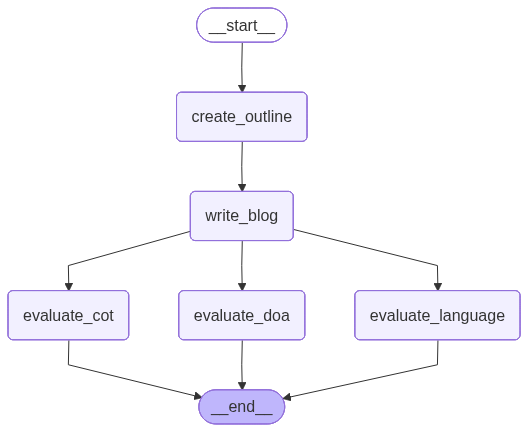

In [57]:
workflow